## Exercício Prático — Aula 01

Use o `df_sujo` criado nesta aula para responder:

1. Qual coluna tem o **maior percentual** de valores ausentes? Calcule e exiba.

2. Preencha os NaN da coluna `'Forma de Pagamento'` com o valor `'Pix'` (simula uma decisão de negócio: qualquer pagamento sem forma registrada foi via Pix). Confirme que não há mais NaN.

3. Para a coluna `'Preço Unitário'`, em vez da mediana, use a **média por Categoria** para preencher os NaN. Ou seja: cada produto deve ter seu NaN preenchido com a média dos outros produtos da mesma categoria. Dica: `groupby + transform('mean')`.

4. Verifique se existem duplicatas apenas considerando as colunas `['Data', 'Loja', 'Produto', 'Quantidade']` (ignora o restante). Quantas encontrou?

5. Crie um gráfico de pizza mostrando a distribuição de **Forma de Pagamento** após a limpeza completa.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("../bases/base_vendas_supermercado.xlsx")

np.random.seed(42)           
df_sujo = df.copy()          

nan_config = {
    'Categoria':          14,   
    'Preço Unitário':     12,   
    'Forma de Pagamento': 10,   
    'Quantidade':          8,   
}
for coluna, qtd in nan_config.items():
    indices = np.random.choice(df_sujo.index, size=qtd, replace=False)
    df_sujo.loc[indices, coluna] = np.nan

duplicatas = df_sujo.sample(n=12, random_state=7)
df_sujo = pd.concat([df_sujo, duplicatas], ignore_index=True)
df_sujo = df_sujo.sample(frac=1, random_state=3).reset_index(drop=True)

print(f"Tamanho da base suja: {df_sujo.shape[0]} linhas.")

d:\SENAI\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
d:\SENAI\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


Tamanho da base suja: 262 linhas.


In [3]:
pct_nan = (df_sujo.isnull().mean() * 100).round(2)
print("Percentual de nulos por coluna:")
print(pct_nan.sort_values(ascending=False).to_string())

Percentual de nulos por coluna:
Categoria             6.11
Preço Unitário        4.58
Forma de Pagamento    3.82
Quantidade            3.44
Cliente               0.00
Loja                  0.00
Data                  0.00
Produto               0.00
Desconto %            0.00
Valor Bruto           0.00
Valor Desconto        0.00
Valor Líquido         0.00


In [4]:
df_ex2 = df_sujo.copy()
df_ex2['Forma de Pagamento'] = df_ex2['Forma de Pagamento'].fillna('Pix')
nulos_pagamento = df_ex2['Forma de Pagamento'].isnull().sum()
print(f"Quantidade de nulos em 'Forma de Pagamento' após o tratamento: {nulos_pagamento}")

Quantidade de nulos em 'Forma de Pagamento' após o tratamento: 0


In [5]:
df_ex3 = df_sujo.copy()
media_por_cat = df_ex3.groupby('Categoria')['Preço Unitário'].transform('mean')
df_ex3['Preço Unitário'] = df_ex3['Preço Unitário'].fillna(media_por_cat)
print(f"NaN restantes em 'Preço Unitário': {df_ex3['Preço Unitário'].isnull().sum()}")

NaN restantes em 'Preço Unitário': 1


In [6]:
colunas_analise = ['Data', 'Loja', 'Produto', 'Quantidade']
total_duplicatas_subset = df_sujo.duplicated(subset=colunas_analise).sum()
print(f"Duplicatas encontradas no subconjunto: {total_duplicatas_subset}")

Duplicatas encontradas no subconjunto: 12


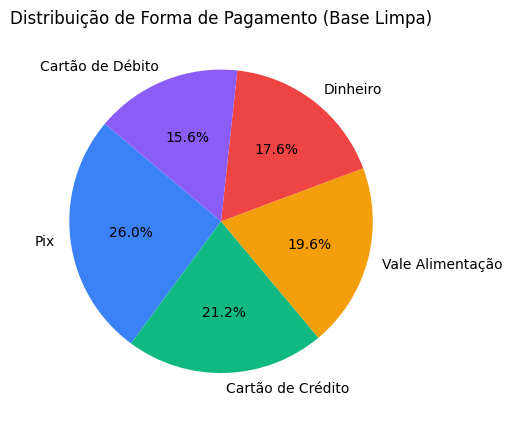

In [10]:
df_limpo_final = df_sujo.copy()

df_limpo_final = df_limpo_final.drop_duplicates()
df_limpo_final['Categoria'] = df_limpo_final['Categoria'].fillna(df_limpo_final['Categoria'].mode()[0])
df_limpo_final['Forma de Pagamento'] = df_limpo_final['Forma de Pagamento'].fillna('Pix')
df_limpo_final['Quantidade'] = df_limpo_final['Quantidade'].fillna(df_limpo_final['Quantidade'].median())
media_cat_final = df_limpo_final.groupby('Categoria')['Preço Unitário'].transform('mean')
df_limpo_final['Preço Unitário'] = df_limpo_final['Preço Unitário'].fillna(media_cat_final)

contagem_pagamentos = df_limpo_final['Forma de Pagamento'].value_counts()

contagem_pagamentos = df_limpo_final['Forma de Pagamento'].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(
    contagem_pagamentos.values, 
    labels=contagem_pagamentos.index, 
    autopct='%1.1f%%', 
    startangle=140,
    colors=['#3b82f6', '#10b981', '#f59e0b', '#ef4444', '#8b5cf6']
)
plt.title('Distribuição de Forma de Pagamento (Base Limpa)')
plt.tight_layout()
plt.show()